In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [2]:
from google.colab import files

uploaded = files.upload()

Saving DEI_dataset.csv to DEI_dataset.csv


In [3]:
df = pd.read_csv(
    "DEI_dataset.csv"
)

In [4]:
df.head()
df.columns

Index(['age', 'gender', 'daily_screen_time_hours', 'social_media_hours',
       'gaming_hours', 'work_study_hours', 'sleep_hours',
       'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time',
       'stress_level', 'academic_work_impact', 'addiction_level',
       'addicted_label', 'weekend_usage_difference', 'sleep_deficit',
       'notification_intensity', 'weekend_overuse', 'DEI', 'DEI_Category'],
      dtype='object')

In [5]:
#Create Attention Score
#Research assumption:
#Attention decreases when:
#Screen Time increases
#Social Media increases
#Gaming increases
#Sleep decreases
#DEI increases

df['attention_score'] = (

    100

    -

    (
        3 * df['daily_screen_time_hours']
    )

    -

    (
        2 * df['social_media_hours']
    )

    -

    (
        1.5 * df['gaming_hours']
    )

    +

    (
        2 * df['sleep_hours']
    )

    -

    (
        0.3 * df['DEI']
    )

)

In [6]:
df['attention_score'] = (
    df['attention_score']
    .clip(0,100)
)

In [7]:
df['attention_category'] = pd.cut(

    df['attention_score'],

    bins=[0,40,70,100],

    labels=[
        'Low',
        'Moderate',
        'High'
    ],

    include_lowest=True

)

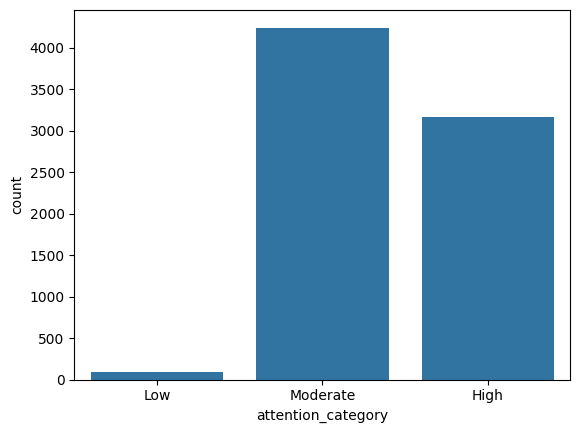

In [8]:
sns.countplot(
    data=df,
    x='attention_category'
)

plt.show()

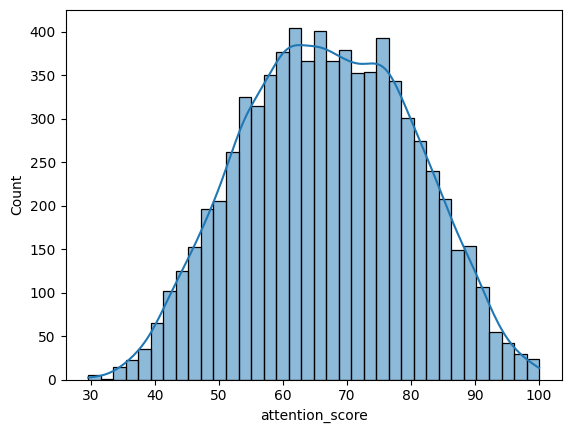

In [9]:
sns.histplot(
    data=df,
    x='attention_score',
    kde=True
)

plt.show()

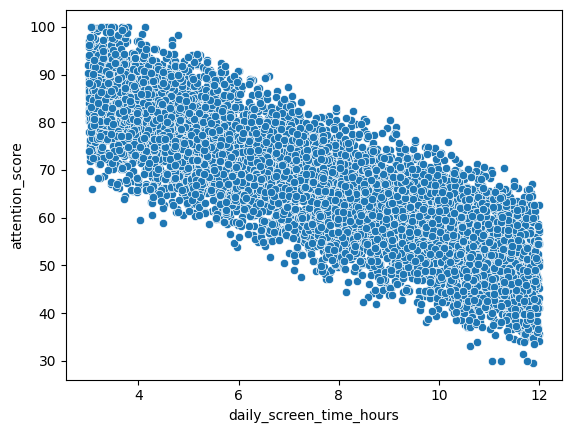

In [10]:
sns.scatterplot(
    data=df,
    x='daily_screen_time_hours',
    y='attention_score'
)

plt.show()

In [11]:
features = [

    'daily_screen_time_hours',

    'social_media_hours',

    'gaming_hours',

    'sleep_hours',

    'notifications_per_day',

    'app_opens_per_day',

    'DEI'

]

In [12]:
X = df[features]

y = df[
    'attention_category'
]

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (6000, 7)
X_test shape: (1500, 7)
y_train shape: (6000,)
y_test shape: (1500,)


In [15]:
model = RandomForestClassifier(

    n_estimators=100,

    random_state=42

)

In [16]:
model.fit(
    X_train,
    y_train
)

RandomForestClassifier(random_state=42)

In [17]:
predictions = model.predict(
    X_test
)

In [18]:
accuracy_score(
    y_test,
    predictions
)

0.964

In [19]:
print(

    classification_report(
        y_test,
        predictions
    )

)

              precision    recall  f1-score   support

        High       0.95      0.97      0.96       643
         Low       0.94      0.77      0.85        22
    Moderate       0.97      0.96      0.97       835

    accuracy                           0.96      1500
   macro avg       0.96      0.90      0.93      1500
weighted avg       0.96      0.96      0.96      1500



In [20]:
cm = confusion_matrix(
    y_test,
    predictions
)

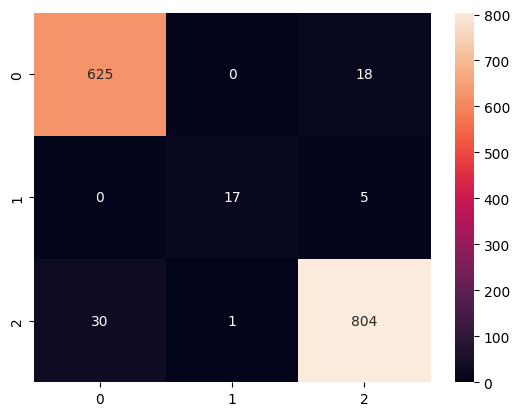

In [21]:
sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.show()

In [22]:
importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance':
    model.feature_importances_

})

In [23]:
importance = importance.sort_values(

    by='Importance',

    ascending=False

)

In [24]:
importance

,Feature,Importance
6,DEI,0.573644
0,daily_screen_time_hours,0.287278
1,social_media_hours,0.052917
3,sleep_hours,0.039129
2,gaming_hours,0.022021
4,notifications_per_day,0.013209
5,app_opens_per_day,0.011801


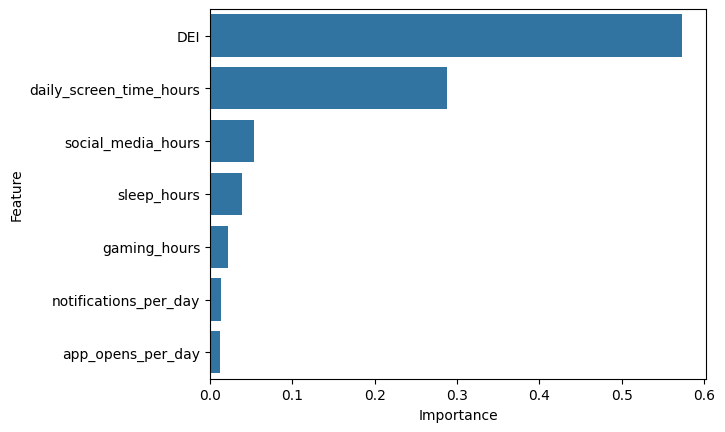

In [25]:
sns.barplot(

    data=importance,

    x='Importance',

    y='Feature'

)

plt.show()

Research Findings

1. Screen time is the strongest predictor
of attention decline.

2. Sleep hours positively impact
attention score.

3. Social media usage reduces
attention score.

4. DEI contributes significantly
to lower attention.

In [26]:
df.to_csv(
    "attention_dataset.csv",
    index=False
)

In [27]:
from google.colab import files

files.download(
    "attention_dataset.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>